# Batch preprocessing verification - pilot subject + small-batch stress test

**Objective**: Verify that the refactored functions in `src/preprocessing.py`(`load_and_prepare_raw`, `bipolarEOG`, `demean`, `apply_filters`,
`detect_artefact_segments`, `amplitude_guard`, `duration_guard`) reproduce the validated behaviour from `02_preprocessing_pilot.ipynb` on the pilot subject (`sub-87999321`), then extend testing to a small batch of additional subjects (5-8) before scaling to the full cohort (n=163).

**Inputs**:
- `src/preprocessing.py` - reusable preprocessing functions
- `data/cohort_filtered_n163.xlsx` - filtered cohort subject list
- TDBRAIN Dataset V3.1, BDF/BIDS format (`data/TDBRAIN_Dataset_V3_1/`)

**Assumptions**:
- Pilot-subject thresholds (`blink_amplitude_threshold_uv=1000`, `trim_pct=2`,
  `blink_duration_threshold=100`) are provisional defaults, not yet validated
  across subjects - this notebook's small-batch section exists specifically
  to stress-test them.
- `detect_artefact_segments` always applies trimmed z-scoring, including for
  VEOG - a deliberate deviation from `02_preprocessing_pilot.ipynb`'s
  standard z-scoring on VEOG. Confirmed on the pilot subject to surface
  additional genuine blinks missed by the untrimmed method (see below).

**Structure**:
1. Re-run each function against the pilot subject, confirming outputs match (or explainably diverge from) the validated notebook results.
2. Extend to a small batch (5–8 subjects), selected to stress-test the
   empirically-fit thresholds against noisier or differently-shaped
   recordings.

In [5]:
import sys
from pathlib import Path

project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))

In [6]:
# imports and setup
from src.preprocessing import (
    find_repo_root, load_and_prepare_raw, bipolarEOG, demean, apply_filters,
    detect_artefact_segments, amplitude_guard, duration_guard
)
import mne
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sys

project_root = find_repo_root()
data_dir = project_root / "data"

In [7]:
# load pilot subject
TDBRAIN_participant_data = pd.read_excel(data_dir / "cohort_filtered_n163.xlsx")
pilot_subject = TDBRAIN_participant_data.iloc[0]
subject_id = pilot_subject['TDBRAIN_ID']
condition = 'restEC'

raw = load_and_prepare_raw(subject_id, condition, data_dir)
raw = bipolarEOG(raw)
raw = demean(raw)

Extracting BDF parameters from /Users/romyweinstock/eeg-rtms-response-prediction/data/TDBRAIN_Dataset_V3_1/sub-87999321/ses-1/eeg/sub-87999321_ses-1_task-restEC_eeg.bdf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 60499  =      0.000 ...   120.998 secs...
Creating RawArray with float64 data, n_channels=2, n_times=60500
    Range : 0 ... 60499 =      0.000 ...   120.998 secs
Ready.


In [8]:
# verify demeaning
demean_picks = mne.pick_types(raw.info, eeg=True, eog=True, ecg=True, emg=False, stim=False)
print(raw.get_data(picks=demean_picks).mean(axis=1))   # should all be ~0
print(raw.get_data(picks=['Mass']).mean())              # EMG excluded, should NOT be ~0

[-1.76167620e-19  1.16711049e-18  1.71763430e-18  7.63393022e-19
  2.64251431e-19 -2.34890161e-18 -9.17539690e-22  1.83507938e-20
  2.23879684e-19 -7.34031752e-20  3.57840479e-20  2.00023652e-19
 -1.87728621e-18 -1.52311589e-19  4.47759369e-19 -9.95530563e-20
  1.37630953e-19  1.90389486e-19 -2.34890161e-19  1.02764445e-18
  6.89989847e-19 -2.06446430e-19  5.30337941e-19  2.93612701e-20
 -7.59722863e-19  8.25785721e-20 -3.08293336e-19 -6.60628577e-19
  1.17445080e-19]
-0.0027585246785445743


In [9]:
# verify filtering changed the signal
before = raw.get_data(picks=['Fp1']).copy()
raw = apply_filters(raw)
after = raw.get_data(picks=['Fp1'])
print(np.allclose(before, after))   # should be False

False


In [10]:
# artefact detection - VEOG and HEOG
Fs = raw.info['sfreq']

veog_data = raw.get_data(picks=['VEOG'])[0]
veog_segments = detect_artefact_segments(veog_data, Fs)
print("VEOG segments:", veog_segments)

heog_data = raw.get_data(picks=['HEOG'])[0]
heog_segments = detect_artefact_segments(heog_data, Fs)
print("HEOG segments:", heog_segments)

VEOG segments: [[10129 10257]
 [11784 18643]
 [20870 21212]
 [58241 60500]]
HEOG segments: [[11294 19471]
 [58543 60500]]


In [11]:
# guards - VEOG
veog_valid_amp, veog_excluded_amp = amplitude_guard(veog_data, veog_segments, threshold=1000)
veog_valid_dur, veog_excluded_dur = duration_guard(veog_valid_amp, Fs, blink_duration_threshold=100)

print("After amplitude_guard:", veog_valid_amp, "| excluded:", veog_excluded_amp)
print("After duration_guard:", veog_valid_dur, "| excluded:", veog_excluded_dur)

After amplitude_guard: [(np.int64(10129), np.int64(10257)), (np.int64(20870), np.int64(21212))] | excluded: [(np.int64(11784), np.int64(18643)), (np.int64(58241), np.int64(60500))]
After duration_guard: [(np.int64(10129), np.int64(10257)), (np.int64(20870), np.int64(21212))] | excluded: []


In [12]:
# guards - HEOG
heog_valid_amp, heog_excluded_amp = amplitude_guard(heog_data, heog_segments, threshold=1000)
heog_valid_dur, heog_excluded_dur = duration_guard(heog_valid_amp, Fs, blink_duration_threshold=100)

print("After amplitude_guard:", heog_valid_amp, "| excluded:", heog_excluded_amp)
print("After duration_guard:", heog_valid_dur, "| excluded:", heog_excluded_dur)

After amplitude_guard: [] | excluded: [(np.int64(11294), np.int64(19471)), (np.int64(58543), np.int64(60500))]
After duration_guard: [] | excluded: []


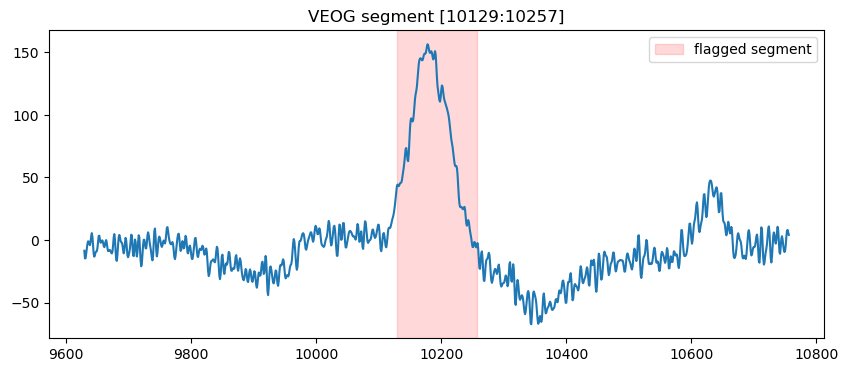

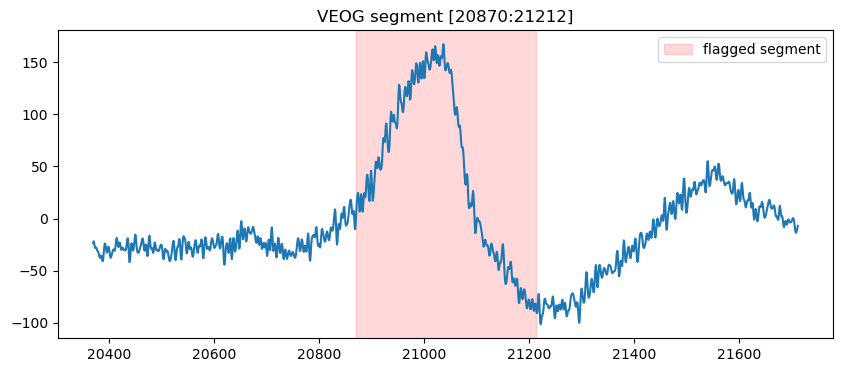

In [13]:
# visual check - the two new VEOG segments surfaced by trimmed z-scoring
veog_1e6 = veog_data * 1e6

for (start, end) in [(10129, 10257), (20870, 21212)]:
    margin = 500
    window = slice(max(0, start - margin), end + margin)
    x = range(window.start, window.stop)
    plt.figure(figsize=(10, 4))
    plt.plot(x, veog_1e6[window])
    plt.axvspan(start, end, color='red', alpha=0.15, label='flagged segment')
    plt.title(f'VEOG segment [{start}:{end}]')
    plt.legend()
    plt.show()

## Summary: pilot-subject verification

All seven functions in `src/preprocessing.py` reproduce validated behaviour
from `02_preprocessing_pilot.ipynb` on `sub-87999321` (restEC), with one
confirmed deliberate deviation:

- `load_and_prepare_raw`, `bipolarEOG`, `demean`, `apply_filters`: outputs
  match expected behaviour (channel means ~0 post-demean, EMG untouched,
  signal changed post-filtering).
- `detect_artefact_segments` (HEOG): output identical to notebook's
  `Atrl_padded_h_EC` - `[[11294, 19471], [58543, 60500]]`.
- `detect_artefact_segments` (VEOG): output diverges from the notebook -
  4 segments vs. the notebook's 2 - because this function always applies
  trimmed z-scoring (`trim_pct=2`), including for VEOG, whereas the notebook
  used standard z-scoring for VEOG. The two segments matching the notebook's
  original candidates are still found; two additional segments
  (`[10129:10257]`, `[20870:21212]`) are new detections.
- Guards on HEOG: both original candidates correctly excluded by the
  amplitude guard (non-ocular step artefacts, matches notebook's "0 valid
  segments" finding for restEC).
- Guards on VEOG: the two notebook-matching segments correctly excluded by
  the amplitude guard. The two new segments pass both guards and were
  visually confirmed as genuine blinks (smooth rise/fall, ~150–165 µV peaks,
  within the <300–400 µV typical range) - evidence that trimmed z-scoring
  catches real blinks that standard z-scoring missed on this subject, likely
  due to std inflation from the same non-ocular artefacts that affected HEOG.

**Residual assumption**: this VEOG behaviour has only been checked on one
subject. Whether trimmed z-scoring is uniformly beneficial (vs. occasionally
introducing false positives) across the full cohort is untested - this is
one of the specific questions the small-batch stress test below is designed
to answer.